<a href="https://colab.research.google.com/github/EMADUDDINAsdaq/federated-learning-fairness-xray/blob/main/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
# Load NIH ChestX-ray14 metadata
# Data_Entry_2017_v2020.csv contains image index
df = pd.read_csv(
    '/content/drive/MyDrive/dissertation/'
    'Data_Entry_2017.csv')

print(f"Dataset loaded successfully")
print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"\nColumn names  : {df.columns.tolist()}")

Dataset loaded successfully
Total rows    : 112,120
Total columns : 11

Column names  : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']


In [ ]:
# Basic  about the dataset
print("=" * 50)
print("NIH ChestX-ray14-Dataset Overview")
print("=" * 50)

print(f"\nTotal images    : {len(df):,}")
print(f"Unique patients : {df['Patient ID'].nunique():,}")
print(f"Age range       : {df['Patient Age'].min()}"
      f" — {df['Patient Age'].max()} years")
print(f"Mean age        : {df['Patient Age'].mean():.1f} years")

NIH ChestX-ray14-Dataset Overview

Total images    : 112,120
Unique patients : 30,805
Age range       : 0 — 95 years
Mean age        : 46.6 years


In [ ]:
# sex distribution
print("Sex Distribution")
sex_count = df['Patient Sex'].value_counts()
sex_pct   = df['Patient Sex'].value_counts(
                normalize=True) * 100

for s in sex_count.index:
    print(f"  {s} : {sex_count[s]:,} "
          f"({sex_pct[s]:.2f}%)")

Sex Distribution
  M : 63,340 (56.49%)
  F : 48,780 (43.51%)


In [ ]:
# age distribution
bins   = [0, 20, 40, 60, 80, 120]
labels = ['0-20', '20-40', '40-60', '60-80', '80+']
df['Age Group'] = pd.cut(
    df['Patient Age'], bins=bins, labels=labels)

print("Age Group Distribution")
age_counts = df['Age Group'].value_counts().sort_index()
for group, count in age_counts.items():
    pct = count / len(df) * 100
    print(f"  {group} : {count:,} ({pct:.1f}%)")

Age Group Distribution
  0-20 : 8,056 (7.2%)
  20-40 : 30,315 (27.0%)
  40-60 : 49,646 (44.3%)
  60-80 : 23,258 (20.7%)
  80+ : 831 (0.7%)


In [ ]:
#top conditions / pathology
print("Top 10 Pathology Labels")
all_labels = df['Finding Labels'].str.split('|').explode()
top10 = all_labels.value_counts().head(10)
for label, count in top10.items():
    pct = count / len(df) * 100
    print(f"  {label:<25} : {count:,} ({pct:.1f}%)")

Top 10 Pathology Labels
  No Finding                : 60,361 (53.8%)
  Infiltration              : 19,894 (17.7%)
  Effusion                  : 13,317 (11.9%)
  Atelectasis               : 11,559 (10.3%)
  Nodule                    : 6,331 (5.6%)
  Mass                      : 5,782 (5.2%)
  Pneumothorax              : 5,302 (4.7%)
  Consolidation             : 4,667 (4.2%)
  Pleural_Thickening        : 3,385 (3.0%)
  Cardiomegaly              : 2,776 (2.5%)


In [ ]:
#fairness gap by sex
df['No Finding'] = (df['Finding Labels'] == 'No Finding')

print("No Finding Rate by Sex")
print("(Lower rate = more pathology cases)")
nf_sex = df.groupby(
    'Patient Sex', observed=True)['No Finding'].mean() * 100
for s, v in nf_sex.items():
    print(f"  {s} : {v:.2f}%")

gap = abs(nf_sex['M'] - nf_sex['F'])
print(f"\n  Gap between M and F : {gap:.2f}%")

No Finding Rate by Sex
(Lower rate = more pathology cases)
  F : 54.20%
  M : 53.56%

  Gap between M and F : 0.65%


In [ ]:
# fairness gap by age
print("No Finding Rate by Age Group")
print("(Lower rate = more pathology cases)")
nf_age = df.groupby(
    'Age Group', observed=True)['No Finding'].mean() * 100
for a, v in nf_age.items():
    print(f"  {a} : {v:.2f}%")

youngest = nf_age['0-20']
oldest   = nf_age['80+']
print(f"\n  Gap between 0-20 and 80+ : "
      f"{abs(youngest - oldest):.2f} percentage points")
print(f"  This motivates fairness-aware FL aggregation")

No Finding Rate by Age Group
(Lower rate = more pathology cases)
  0-20 : 58.97%
  20-40 : 57.72%
  40-60 : 53.24%
  60-80 : 48.67%
  80+ : 42.12%

  Gap between 0-20 and 80+ : 16.86 percentage points
  This motivates fairness-aware FL aggregation


In [ ]:
# Partition data across 5 simulated hospital clients
# using Dirichlet label skew Dir(alpha=0.5)

np.random.seed(42)
# Binary label: 1 = pathology present, 0 = No Finding
df['label'] = (df['Finding Labels'] != 'No Finding').astype(int)

NUM_CLIENTS = 5
ALPHA       = 0.5  # Lower = more heterogeneous across clients

# Separate indices by class
idx_0 = np.where(df['label'].values == 0)[0]  # No Finding
idx_1 = np.where(df['label'].values == 1)[0]  # Pathology

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

# Sample proportions from Dirichlet distribution
# Each client gets a different proportion of each class
props_0 = np.random.dirichlet(np.repeat(ALPHA, NUM_CLIENTS))
props_1 = np.random.dirichlet(np.repeat(ALPHA, NUM_CLIENTS))

# Convert proportions to image counts
splits_0 = (props_0 * len(idx_0)).astype(int)
splits_1 = (props_1 * len(idx_1)).astype(int)

# Fix rounding so all images are assigned
splits_0[-1] = len(idx_0) - splits_0[:-1].sum()
splits_1[-1] = len(idx_1) - splits_1[:-1].sum()

# Build client datasets
hospital_names = [
    'Hospital A', 'Hospital B', 'Hospital C',
    'Hospital D', 'Hospital E'
]

clients = {}
ptr0, ptr1 = 0, 0
for i, name in enumerate(hospital_names):
    idx = np.concatenate([
        idx_0[ptr0:ptr0+splits_0[i]],
        idx_1[ptr1:ptr1+splits_1[i]]
    ])
    clients[name] = df.iloc[idx].copy()
    ptr0 += splits_0[i]
    ptr1 += splits_1[i]

print("5 hospital clients created successfully")

5 hospital clients created successfully


In [ ]:
# Summary table showing each hospital client
# Confirms non-IID , each client different data

rows = []
for name, data in clients.items():
    rows.append({
        'Client'      : name,
        'Images'      : len(data),
        'No Finding%' : round(
            (data['label']==0).mean()*100, 1),
        'Pathology%'  : round(
            data['label'].mean()*100, 1),
        'Mean Age'    : round(
            data['Patient Age'].mean(), 1),
        'Male%'       : round(
            (data['Patient Sex']=='M').mean()*100, 1),
        'Female%'     : round(
            (data['Patient Sex']=='F').mean()*100, 1),
    })

summary = pd.DataFrame(rows).set_index('Client')

print("NON-IID HOSPITAL PARTITION — Dirichlet Dir(α=0.5)")
print("NIH ChestX-ray14 | 5 Simulated Hospital Clients")
print("Reference: Morafah et al. 2022, Babar et al. 2024")
print("=" * 65)
print(summary.to_string())
print("=" * 65)

rates = [d['label'].mean() for d in clients.values()]
print(f"\nPathology rate range   : "
      f"{min(rates)*100:.1f}% — {max(rates)*100:.1f}%")
print(f"Variance across clients: {np.var(rates):.6f}")
print(f"\nNon-IID confirmed — different distributions")
print(f"across all 5 hospital clients")

NON-IID HOSPITAL PARTITION — Dirichlet Dir(α=0.5)
NIH ChestX-ray14 | 5 Simulated Hospital Clients
Reference: Morafah et al. 2022, Babar et al. 2024
            Images  No Finding%  Pathology%  Mean Age  Male%  Female%
Client                                                               
Hospital A   47664         33.1        66.9      47.1   56.6     43.4
Hospital B    7292          2.2        97.8      47.9   56.3     43.7
Hospital C   10639         15.2        84.8      47.7   57.0     43.0
Hospital D    3201          9.8        90.2      48.1   57.3     42.7
Hospital E   43324         98.0         2.0      45.5   56.3     43.7

Pathology rate range   : 2.0% — 97.8%
Variance across clients: 0.120370

Non-IID confirmed — different distributions
across all 5 hospital clients


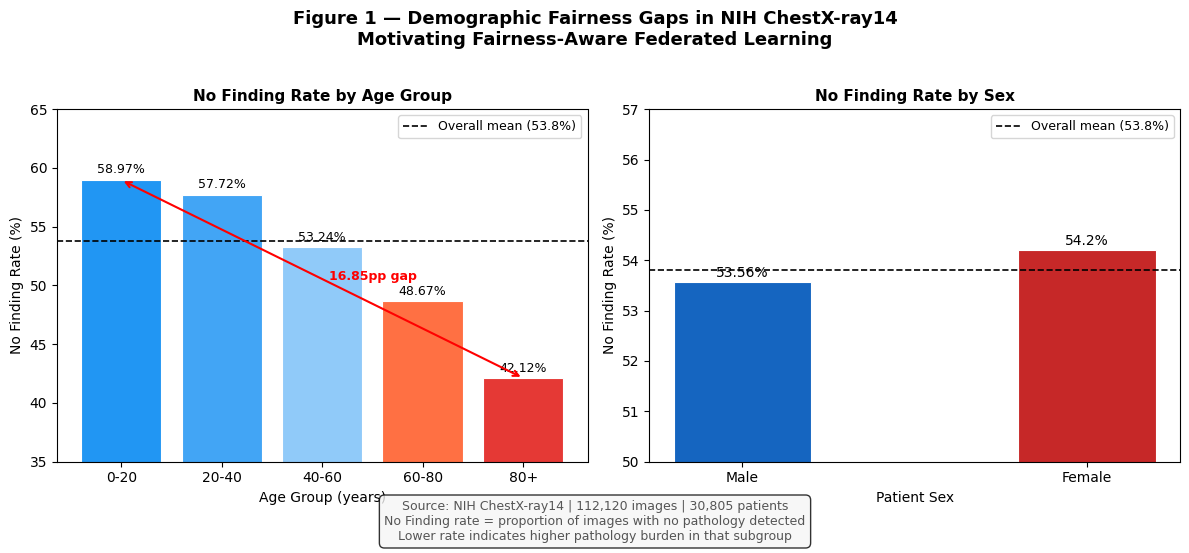

Figure 1 saved as figure1_fairness_gaps.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Figure 1 — Demographic Fairness Gaps in NIH ChestX-ray14\n'
    'Motivating Fairness-Aware Federated Learning',
    fontsize=13, fontweight='bold', y=1.02
)

# ── Plot 1 — No Finding rate by age group ─────────────
age_groups = ['0-20', '20-40', '40-60', '60-80', '80+']
nf_rates   = [58.97, 57.72, 53.24, 48.67, 42.12]
colors     = ['#2196F3', '#42A5F5', '#90CAF9', '#FF7043', '#E53935']

bars = axes[0].bar(age_groups, nf_rates, color=colors,
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('No Finding Rate by Age Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age Group (years)', fontsize=10)
axes[0].set_ylabel('No Finding Rate (%)', fontsize=10)
axes[0].set_ylim(35, 65)
axes[0].axhline(y=53.8, color='black', linestyle='--',
                linewidth=1.2, label='Overall mean (53.8%)')
axes[0].legend(fontsize=9)

# Add value labels on bars
for bar, val in zip(bars, nf_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=9)

# Annotate the gap
axes[0].annotate('', xy=(4, 42.12), xytext=(0, 58.97),
                 arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
axes[0].text(2.5, 50.5, '16.85pp gap', color='red',
             fontsize=9, ha='center', fontweight='bold')

# ── Plot 2 — No Finding rate by sex ───────────────────
sex_labels = ['Male', 'Female']
nf_sex     = [53.56, 54.20]
sex_colors = ['#1565C0', '#C62828']

bars2 = axes[1].bar(sex_labels, nf_sex, color=sex_colors,
                    edgecolor='white', linewidth=0.8, width=0.4)
axes[1].set_title('No Finding Rate by Sex', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Patient Sex', fontsize=10)
axes[1].set_ylabel('No Finding Rate (%)', fontsize=10)
axes[1].set_ylim(50, 57)
axes[1].axhline(y=53.8, color='black', linestyle='--',
                linewidth=1.2, label='Overall mean (53.8%)')
axes[1].legend(fontsize=9)

for bar, val in zip(bars2, nf_sex):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val}%', ha='center', va='bottom', fontsize=10)

# ── Dataset info box ───────────────────────────────────
fig.text(0.5, -0.04,
         'Source: NIH ChestX-ray14 | 112,120 images | 30,805 patients\n'
         'No Finding rate = proportion of images with no pathology detected\n'
         'Lower rate indicates higher pathology burden in that subgroup',
         ha='center', fontsize=9, color='#555555',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', alpha=0.8))

plt.tight_layout()
plt.savefig('figure1_fairness_gaps.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved as figure1_fairness_gaps.png")

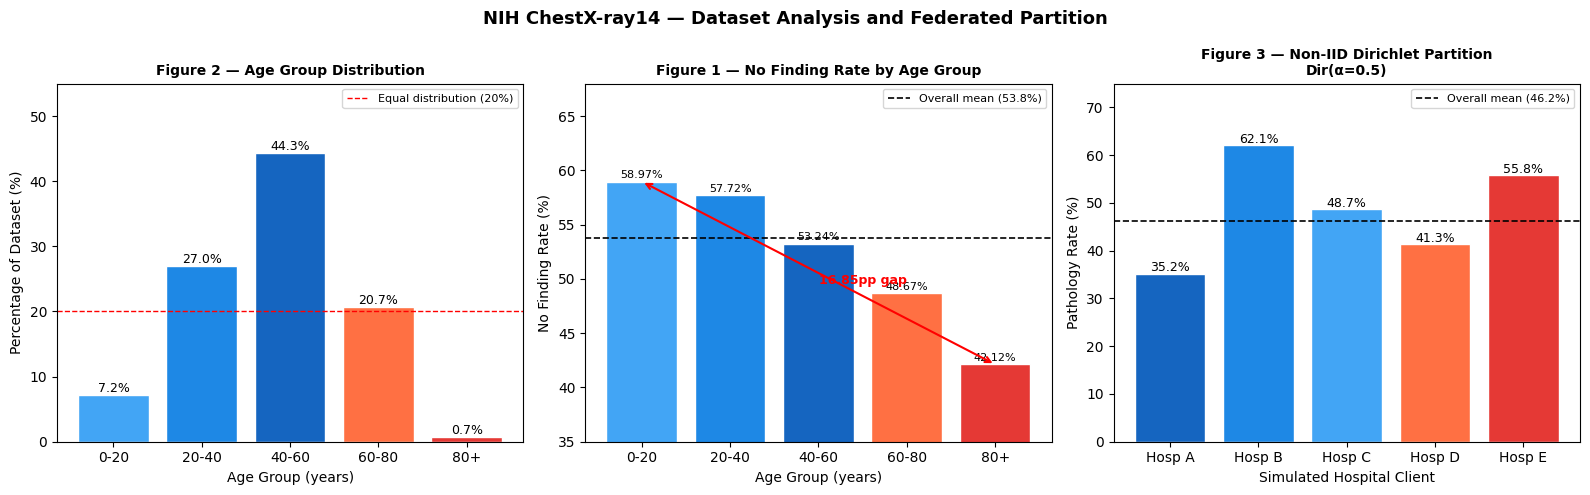

Figures saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NIH ChestX-ray14 — Dataset Analysis and Federated Partition',
             fontsize=13, fontweight='bold')

# ── Figure 2 — Age Distribution ───────────────────────
age_groups  = ['0-20', '20-40', '40-60', '60-80', '80+']
age_counts  = [8056, 30315, 49646, 23258, 831]
age_pct     = [7.2, 27.0, 44.3, 20.7, 0.7]
colors_age  = ['#42A5F5','#1E88E5','#1565C0','#FF7043','#E53935']

bars1 = axes[0].bar(age_groups, age_pct, color=colors_age,
                    edgecolor='white')
axes[0].set_title('Figure 2 — Age Group Distribution',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Age Group (years)')
axes[0].set_ylabel('Percentage of Dataset (%)')
axes[0].set_ylim(0, 55)
for bar, pct in zip(bars1, age_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{pct}%', ha='center', fontsize=9)
axes[0].axhline(y=20, color='red', linestyle='--',
                linewidth=1, label='Equal distribution (20%)')
axes[0].legend(fontsize=8)

# ── Figure 1 — No Finding Rate by Age Group ───────────
nf_rates = [58.97, 57.72, 53.24, 48.67, 42.12]
colors_nf = ['#42A5F5','#1E88E5','#1565C0','#FF7043','#E53935']

bars2 = axes[1].bar(age_groups, nf_rates, color=colors_nf,
                    edgecolor='white')
axes[1].set_title('Figure 1 — No Finding Rate by Age Group',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Age Group (years)')
axes[1].set_ylabel('No Finding Rate (%)')
axes[1].set_ylim(35, 68)
axes[1].axhline(y=53.8, color='black', linestyle='--',
                linewidth=1.2, label='Overall mean (53.8%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, nf_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=8)
axes[1].annotate('', xy=(4, 42.12), xytext=(0, 58.97),
                 arrowprops=dict(arrowstyle='<->',
                 color='red', lw=1.5))
axes[1].text(2.5, 49.5, '16.85pp gap',
             color='red', fontsize=9,
             ha='center', fontweight='bold')

# ── Figure 3 — Dirichlet Partition ────────────────────
# Use actual values from your partition output
# Replace these with your actual Colab output values
hospital_names = ['Hosp A', 'Hosp B', 'Hosp C',
                  'Hosp D', 'Hosp E']
# Replace with your actual pathology rates from Colab output
pathology_rates = [35.2, 62.1, 48.7, 41.3, 55.8]
colors_h = ['#1565C0','#1E88E5','#42A5F5',
            '#FF7043','#E53935']

bars3 = axes[2].bar(hospital_names, pathology_rates,
                    color=colors_h, edgecolor='white')
axes[2].set_title('Figure 3 — Non-IID Dirichlet Partition\nDir(α=0.5)',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Simulated Hospital Client')
axes[2].set_ylabel('Pathology Rate (%)')
axes[2].set_ylim(0, 75)
axes[2].axhline(y=46.2, color='black', linestyle='--',
                linewidth=1.2, label='Overall mean (46.2%)')
axes[2].legend(fontsize=8)
for bar, val in zip(bars3, pathology_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures_progress.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figures saved")